In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier,plot_importance
from sklearn.metrics import classification_report, roc_curve, roc_auc_score,precision_recall_curve
from sklearn.model_selection import GridSearchCV
from tqdm import tqdm
sns.set_style("darkgrid")
path = kagglehub.dataset_download("brycecf/give-me-some-credit-dataset")
train_path = os.path.join(path,'cs-training.csv')
test_path = os.path.join(path,'cs-test.csv')
df = pd.read_csv(train_path,index_col=0)
test_df = pd.read_csv(test_path,index_col=0)

100%|██████████| 5.16M/5.16M [00:02<00:00, 2.59MB/s]

Extracting files...


# Identifying Missing Values and Outliers

In [69]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


(array([0, 1]), [Text(0, 0, '0'), Text(1, 0, '1')])

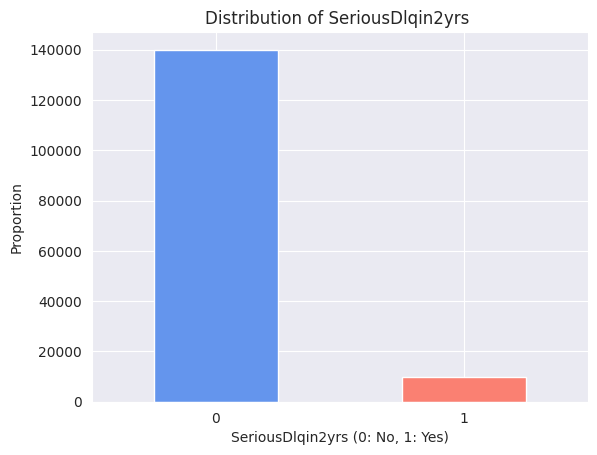

In [70]:
deliqnency = df["SeriousDlqin2yrs"].value_counts()
deliqnency.plot(kind='bar', color=['cornflowerblue', 'salmon'])

plt.title('Distribution of SeriousDlqin2yrs ')
plt.xlabel('SeriousDlqin2yrs (0: No, 1: Yes)')
plt.ylabel('Proportion')
plt.xticks(rotation=0)

The monthly income missing values ratio: 20%
The number of dependents missing values ratio: 3%


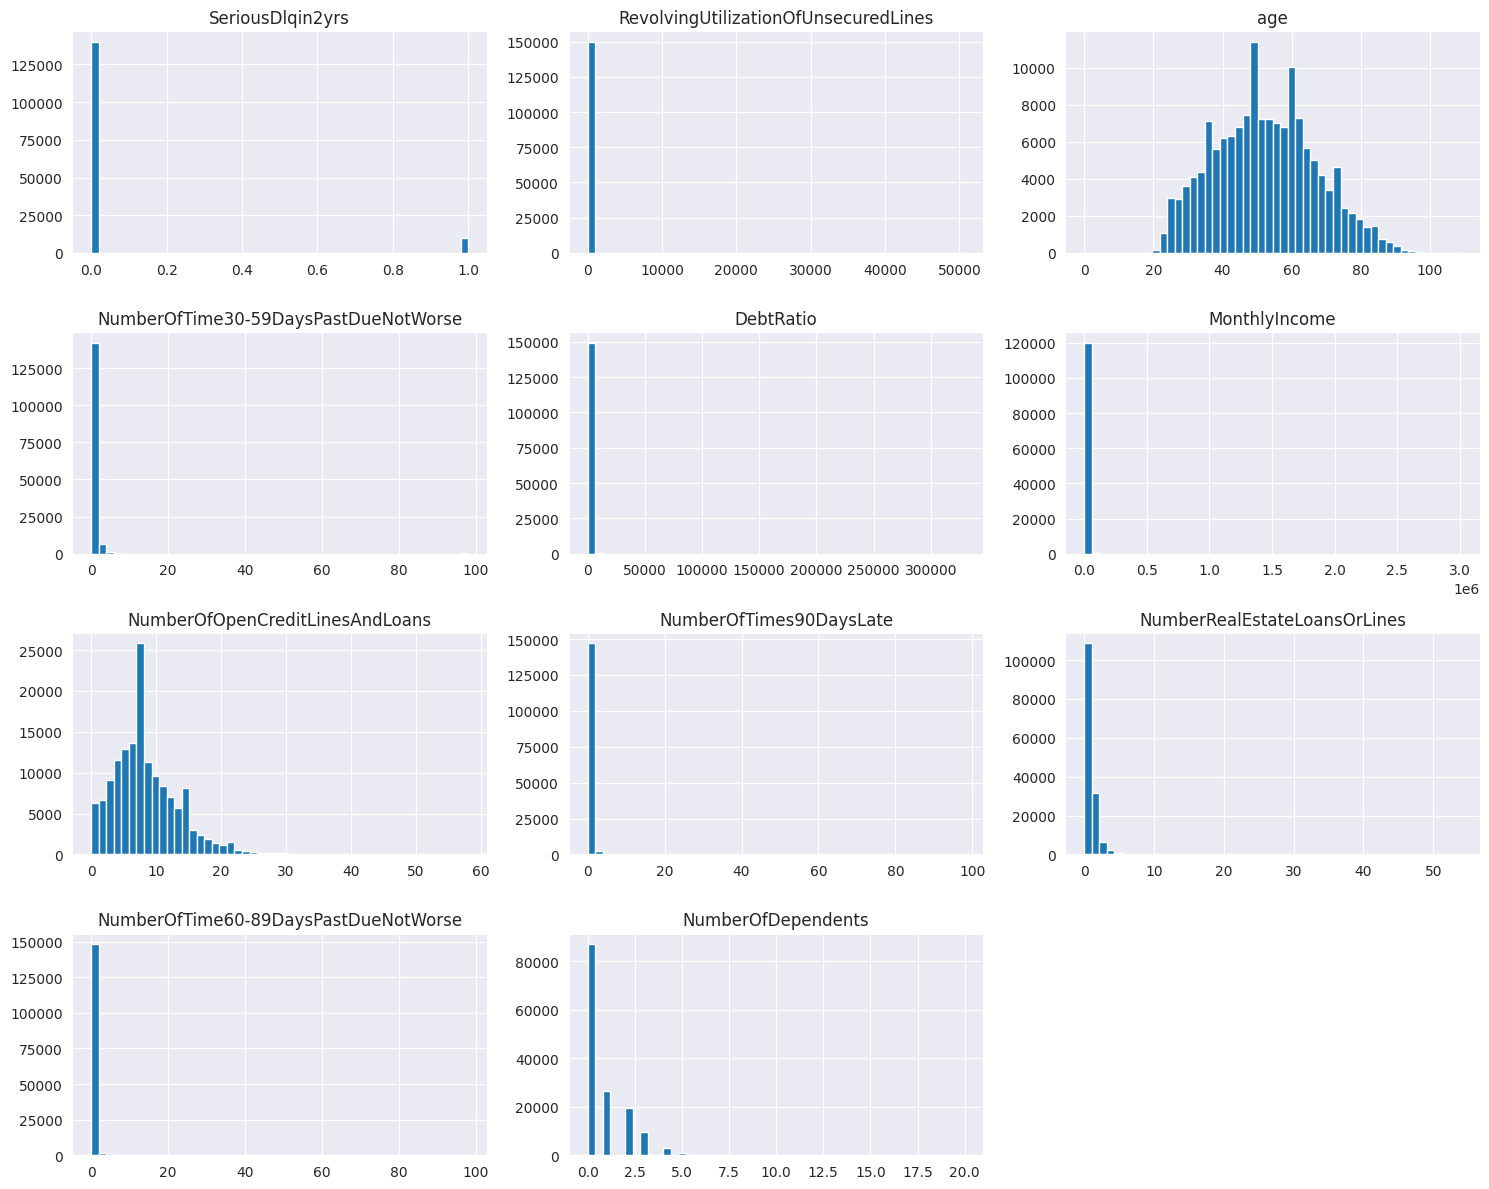

In [71]:
# print(df.isnull().sum())
print(f"The monthly income missing values ratio: {round(df["MonthlyIncome"].isnull().sum() / len(df)*100)}%")
print(f"The number of dependents missing values ratio: {round(df["NumberOfDependents"].isnull().sum() / len(df)*100)}%")

df.hist(figsize=(15, 12), bins=50)
plt.tight_layout()
plt.show()

# Handling Missing Values and Outliers

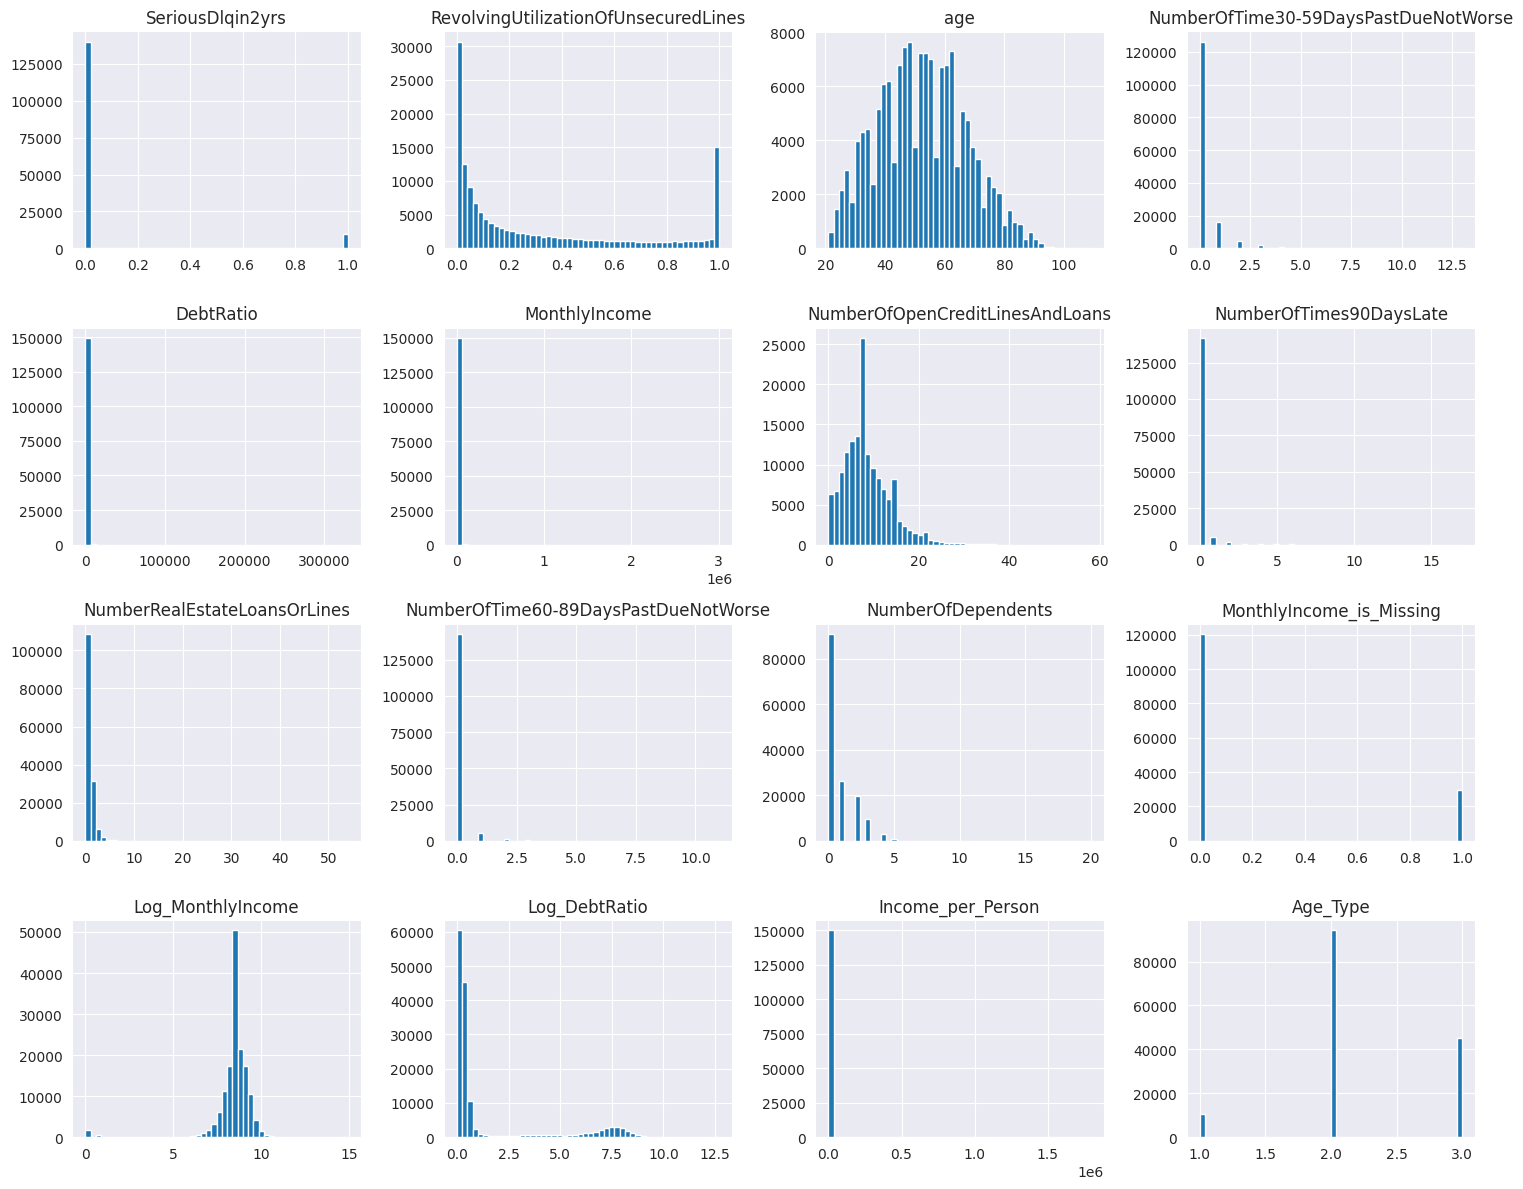

In [72]:
def preprocessor(df):
    df["MonthlyIncome_is_Missing"] = df["MonthlyIncome"].isnull().astype(int)
    df["MonthlyIncome"]=df["MonthlyIncome"].fillna(df["MonthlyIncome"].median())
    df["NumberOfDependents"] = df["NumberOfDependents"].fillna(df["NumberOfDependents"].median())
    df['Log_MonthlyIncome'] = np.log1p(df['MonthlyIncome'])
    df['Log_DebtRatio'] = np.log1p(df["DebtRatio"])
    df.loc[df['age'] < 18, 'age'] = df['age'].median()
    df.loc[df["RevolvingUtilizationOfUnsecuredLines"]>1,"RevolvingUtilizationOfUnsecuredLines"] = 1
    past_due_cols = [
        "NumberOfTime30-59DaysPastDueNotWorse",
        "NumberOfTime60-89DaysPastDueNotWorse",
        "NumberOfTimes90DaysLate"
    ]
    for col in past_due_cols:
        df.loc[df[col]>90,col] = df[col].median()

    df["Income_per_Person"] = df["MonthlyIncome"].fillna(0) / (df["NumberOfDependents"] + 1)

    df["Age_Type"] = pd.cut(df["age"], bins=[0, 30, 60, 150], labels=[1, 2, 3]).astype(int)
    return df

df = preprocessor(df)
test_df = preprocessor(test_df)

df.hist(figsize=(15, 12), bins=50)
plt.tight_layout()
plt.show()

# Correlation Analysis

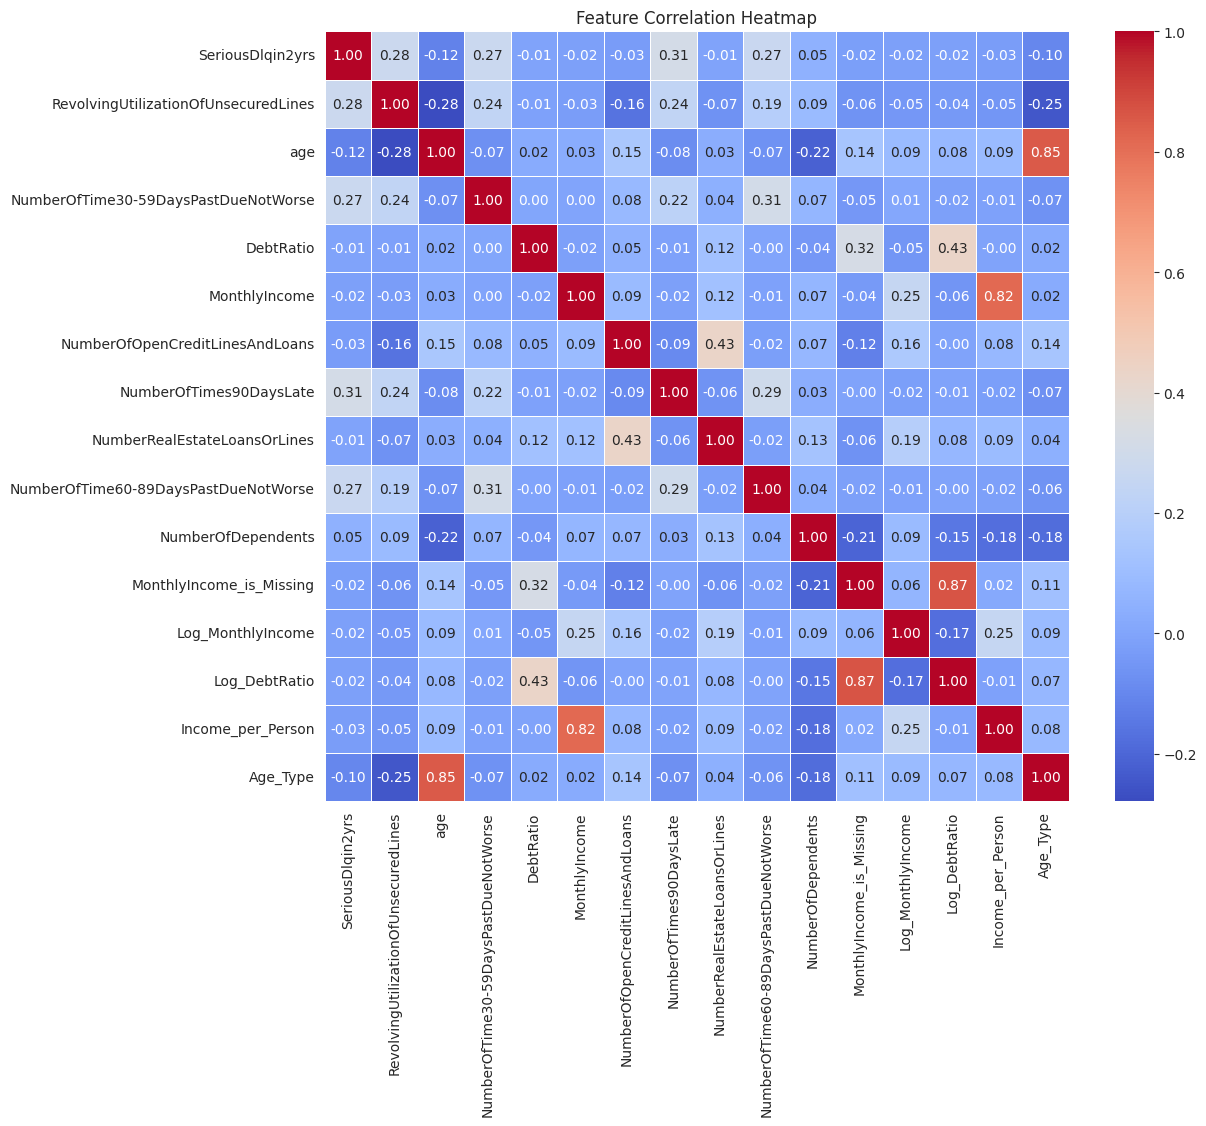

In [73]:
corr_matrix = df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

# Feature Selection

In [74]:
features = [
    'RevolvingUtilizationOfUnsecuredLines','NumberOfTime30-59DaysPastDueNotWorse',
    'Log_MonthlyIncome', "age","Age_Type","Income_per_Person",
    'NumberOfTime60-89DaysPastDueNotWorse','NumberOfTimes90DaysLate',
    'NumberOfDependents', 'MonthlyIncome_is_Missing',"Log_DebtRatio"
]

X = df[features]
y = df['SeriousDlqin2yrs']

In [75]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("The training data size:", X_train.shape)
print("The testing data size::", X_test.shape)
print("\n The delinquency data distribution:\n", y_train.value_counts(normalize=True)) # normalize means transforming frequency into percentage

The training data size: (120000, 11)
The testing data size:: (30000, 11)

 The delinquency data distribution:
 SeriousDlqin2yrs
0    0.933158
1    0.066842
Name: proportion, dtype: float64


# Handling Unbalanced Data

Using SMOTE method doesn't always have a better result, so we need to test out and try more.

In [76]:
print("Before:", Counter(y_train))

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("After:", Counter(y_train_res))

Before: Counter({0: 111979, 1: 8021})
After: Counter({0: 111979, 1: 111979})


# Model Training

In [77]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

xgb = XGBClassifier(n_estimators=130, learning_rate=0.05,max_depth=5,scale_pos_weight=15,random_state=42)

xgb.fit(X_train, y_train)

y_ref_pred = xgb.predict(X_test)
y_ref_probs = xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_ref_pred))

              precision    recall  f1-score   support

           0       0.98      0.78      0.87     27995
           1       0.20      0.79      0.32      2005

    accuracy                           0.78     30000
   macro avg       0.59      0.78      0.60     30000
weighted avg       0.93      0.78      0.83     30000



# Feature Importance

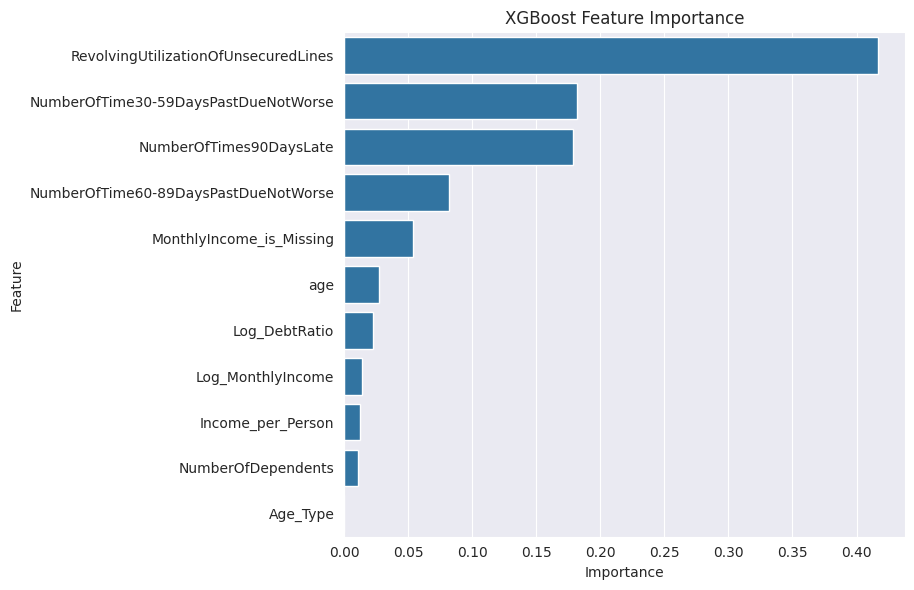

In [78]:
xgb_importance = pd.DataFrame({'Feature': X.columns, 'Importance': xgb.feature_importances_})

xgb_importance = xgb_importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(15,6))
plt.subplot(1, 2, 2)
sns.barplot(x='Importance', y='Feature', data=xgb_importance)
plt.title('XGBoost Feature Importance')

plt.tight_layout()
plt.show()

# ROC

AUC Score : 0.8643


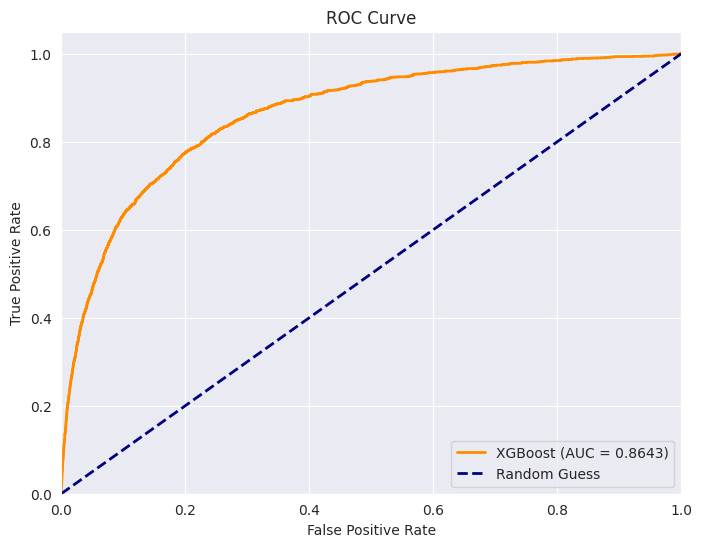

In [79]:
xgb_probs = xgb.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, xgb_probs) # th

xgb_auc = roc_auc_score(y_test, xgb_probs)

print(f"AUC Score : {xgb_auc:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'XGBoost (AUC = {xgb_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

# Customized Decision Threshold

In [80]:
def final_credit_decision(model, data, threshold=0.35):

    probs = model.predict_proba(data)[:, 1]

    decisions = (probs >= threshold).astype(int)

    result = pd.DataFrame({
        'Delinquency Ratio': probs,
        'Predicted Result': ['Reject' if d == 1 else 'Accept' for d in decisions]
    })

    return result

sample_customers = X_test.head(5)
print(final_credit_decision(xgb, sample_customers, threshold=0.35))

   Delinquency Ratio Predicted Result
0           0.110031           Accept
1           0.343457           Accept
2           0.111844           Accept
3           0.159818           Accept
4           0.132080           Accept


# GridSearch

It takes time to proceed, so comment it out only when needed.

In [81]:
# param_grid = {
#     'max_depth': [3, 5, 10],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'n_estimators': [100, 150, 200,250]
# }


# grid_search = GridSearchCV(
#     estimator=xgb,
#     param_grid=param_grid,
#     scoring='roc_auc',
#     cv=5,
#     verbose=1
# )

# grid_search.fit(X_train_res, y_train_res)

# # 5. 輸出結果
# print(grid_search.best_params_)
# print(f" AUC Score: {grid_search.best_score_:.4f}")

# For Kaggle Submission (Not neccessary)

In [82]:
# X_kaggle_test = test_df[X.columns]

# X_kaggle_test = X_kaggle_test.fillna(X_train.median())

# kaggle_probs = xgb.predict_proba(X_kaggle_test)[:, 1]

# submission = pd.DataFrame({
#     'Id': test_df.index,
#     'Probability': kaggle_probs
# })

# submission.to_csv('submission.csv', index=False)